In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch


In [3]:
DATA_DIR = Path("../data/raw")
CSV_PATH = DATA_DIR / "driver_imgs_list.csv"

In [4]:
df = pd.read_csv(CSV_PATH)
df.head()

,subject,classname,img
0,p002,c0,img_44733.jpg
1,p002,c0,img_72999.jpg
2,p002,c0,img_25094.jpg
3,p002,c0,img_69092.jpg
4,p002,c0,img_92629.jpg


In [5]:
df.shape

(22424, 3)

In [6]:
df.columns

Index(['subject', 'classname', 'img'], dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22424 entries, 0 to 22423
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   subject    22424 non-null  str  
 1   classname  22424 non-null  str  
 2   img        22424 non-null  str  
dtypes: str(3)
memory usage: 525.7 KB


In [8]:
df['classname'].nunique()

10

In [9]:
df['classname'].unique()

<StringArray>
['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']
Length: 10, dtype: str

In [10]:
df['img'].value_counts()

img
img_44733.jpg    1
img_72999.jpg    1
img_25094.jpg    1
img_69092.jpg    1
img_92629.jpg    1
                ..
img_56936.jpg    1
img_46218.jpg    1
img_25946.jpg    1
img_67850.jpg    1
img_9684.jpg     1
Name: count, Length: 22424, dtype: int64

In [11]:
df['classname'].value_counts()

classname
c0    2489
c3    2346
c4    2326
c6    2325
c2    2317
c5    2312
c1    2267
c9    2129
c7    2002
c8    1911
Name: count, dtype: int64

In [12]:
df.groupby('subject')['img'].count()

subject
p002     725
p012     823
p014     876
p015     875
p016    1078
p021    1237
p022    1233
p024    1226
p026    1196
p035     848
p039     651
p041     605
p042     591
p045     724
p047     835
p049    1011
p050     790
p051     920
p052     740
p056     794
p061     809
p064     820
p066    1034
p072     346
p075     814
p081     823
Name: img, dtype: int64

In [13]:
df['subject'].nunique()

26

In [14]:
df.groupby('classname')['img'].count()

classname
c0    2489
c1    2267
c2    2317
c3    2346
c4    2326
c5    2312
c6    2325
c7    2002
c8    1911
c9    2129
Name: img, dtype: int64

In [15]:
df.isnull().sum()

subject      0
classname    0
img          0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
TRAIN_DIR = Path("../data/raw/imgs/train")

In [18]:
image_files = list(TRAIN_DIR.glob("c*/*.jpg"))

print("Images listed in CSV:", len(df))
print("Images found on disk:", len(image_files))

Images listed in CSV: 22424
Images found on disk: 22424


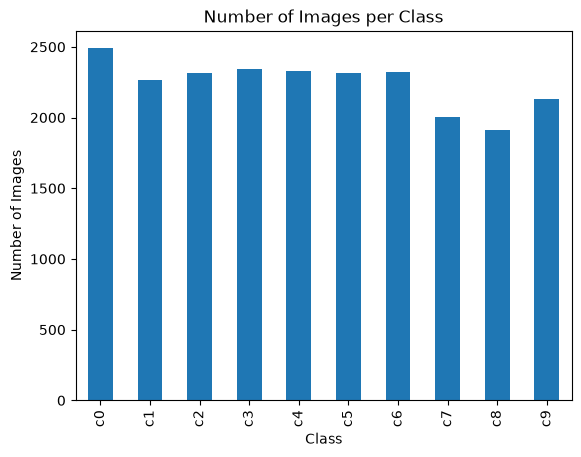

In [19]:
class_counts = df['classname'].value_counts().sort_index()

class_counts.plot(kind='bar')

plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [20]:
df.groupby(['subject','classname'])['img'].count()

subject  classname
p002     c0           76
         c1           74
         c2           86
         c3           79
         c4           84
                      ..
p081     c5           81
         c6           79
         c7           77
         c8           61
         c9           80
Name: img, Length: 260, dtype: int64

In [21]:
df.groupby('subject').count()

,classname,img
subject,,
p002,725,725
p012,823,823
p014,876,876
p015,875,875
p016,1078,1078
p021,1237,1237
p022,1233,1233
p024,1226,1226
p026,1196,1196


In [22]:
df.groupby(['subject','classname']).count().reset_index()

,subject,classname,img
0,p002,c0,76
1,p002,c1,74
2,p002,c2,86
3,p002,c3,79
4,p002,c4,84
...,...,...,...
255,p081,c5,81
256,p081,c6,79
257,p081,c7,77
258,p081,c8,61


In [23]:
driver_class_counts = (
    df.groupby(['subject', 'classname'])['img']
    .count()
    .reset_index(name='image_count')
)
driver_class_counts

,subject,classname,image_count
0,p002,c0,76
1,p002,c1,74
2,p002,c2,86
3,p002,c3,79
4,p002,c4,84
...,...,...,...
255,p081,c5,81
256,p081,c6,79
257,p081,c7,77
258,p081,c8,61


In [24]:
class_counts = df['classname'].value_counts().sort_index()

print(class_counts)

classname
c0    2489
c1    2267
c2    2317
c3    2346
c4    2326
c5    2312
c6    2325
c7    2002
c8    1911
c9    2129
Name: count, dtype: int64


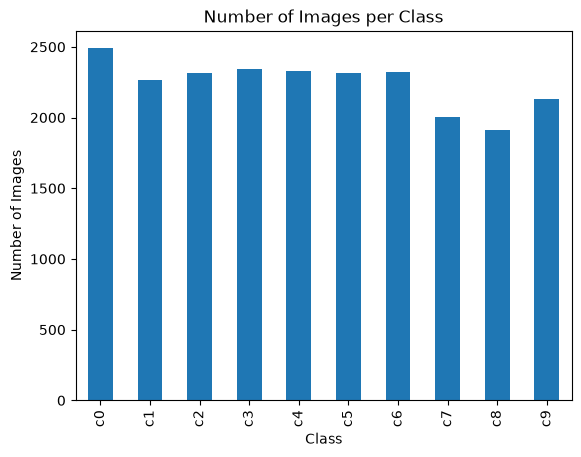

In [25]:
import matplotlib.pyplot as plt

class_counts.plot(kind='bar')

plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [26]:
class_names = {
    'c0': 'Safe driving',
    'c1': 'Texting - right',
    'c2': 'Talking on phone - right',
    'c3': 'Texting - left',
    'c4': 'Talking on phone - left',
    'c5': 'Operating radio',
    'c6': 'Drinking',
    'c7': 'Reaching behind',
    'c8': 'Hair and makeup',
    'c9': 'Talking to passenger',
}

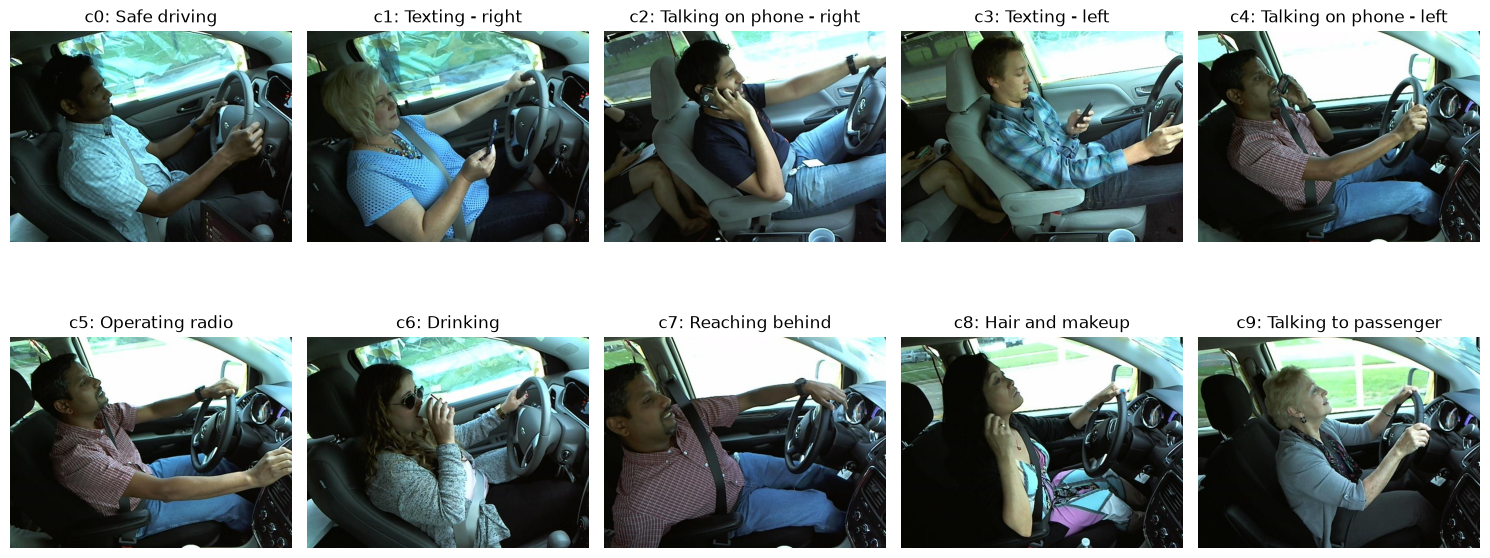

In [27]:
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(15, 7))

for ax, class_name in zip(axes.flatten(), sorted(df['classname'].unique())):

    sample = df[df['classname'] == class_name].sample(1).iloc[0]

    image_path = (
        Path("../data/raw/imgs/train")
        / class_name
        / sample['img']
    )

    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(f"{class_name}: {class_names[class_name]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [28]:
print(class_counts)

classname
c0    2489
c1    2267
c2    2317
c3    2346
c4    2326
c5    2312
c6    2325
c7    2002
c8    1911
c9    2129
Name: count, dtype: int64


In [29]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nUnique drivers:")
print(df["subject"].nunique())

print("\nImages per driver:")
print(df["subject"].value_counts())

Missing values:
subject      0
classname    0
img          0
dtype: int64

Duplicate rows:
0

Unique drivers:
26

Images per driver:
subject
p021    1237
p022    1233
p024    1226
p026    1196
p016    1078
p066    1034
p049    1011
p051     920
p014     876
p015     875
p035     848
p047     835
p012     823
p081     823
p064     820
p075     814
p061     809
p056     794
p050     790
p052     740
p002     725
p045     724
p039     651
p041     605
p042     591
p072     346
Name: count, dtype: int64


In [30]:
from pathlib import Path

train_dir = Path("../data/raw/imgs/train")

image_files = list(train_dir.glob("c*/*.jpg"))

print("Images in CSV:", len(df))
print("Images on disk:", len(image_files))

Images in CSV: 22424
Images on disk: 22424


# Day 3

In [31]:
image_path = Path("../data/raw/imgs/train/c0")


In [32]:
image_file = list(image_path.glob("*.jpg"))[0]

In [33]:
image = Image.open(image_file)

In [34]:
print(image_file)
print(image.size)
print(image.mode)

../data/raw/imgs/train/c0/img_46818.jpg
(640, 480)
RGB


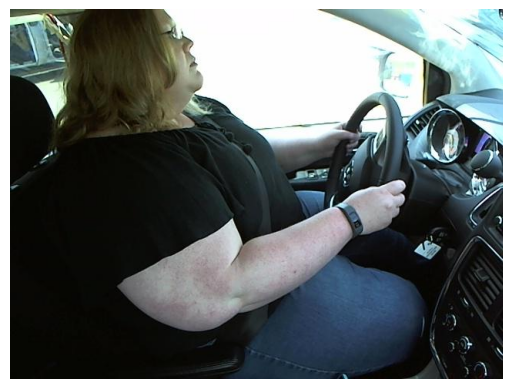

In [35]:
plt.imshow(image)
plt.axis("off")
plt.show()

In [36]:
numpy_array = np.array(image)

In [37]:
print(numpy_array.shape)

(480, 640, 3)


In [38]:
print(numpy_array[0, 0])

[60 74 57]


In [39]:
print("Shape:", numpy_array.shape)
print("Data type:", numpy_array.dtype)
print("Min pixel value:", numpy_array.min())
print("Max pixel value:", numpy_array.max())

Shape: (480, 640, 3)
Data type: uint8
Min pixel value: 0
Max pixel value: 255


In [40]:
red_channel = numpy_array[:, :, 0]
green_channel = numpy_array[:, :, 1]
blue_channel = numpy_array[:, :, 2]

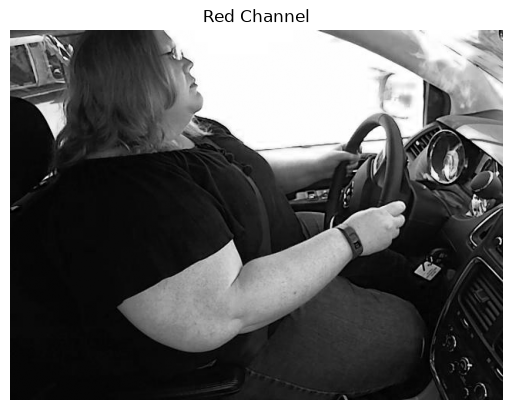

In [41]:
plt.imshow(red_channel, cmap="gray")
plt.title("Red Channel")
plt.axis("off")
plt.show()

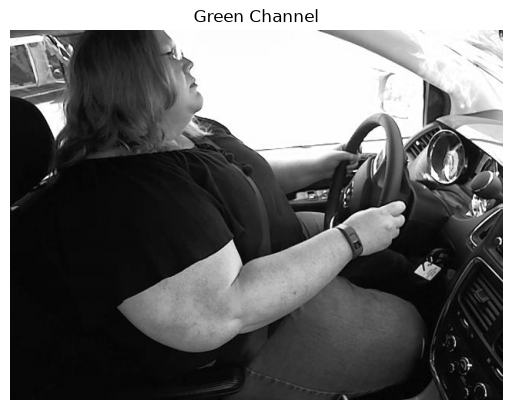

In [42]:
plt.imshow(green_channel, cmap="gray")
plt.title("Green Channel")
plt.axis("off")
plt.show()

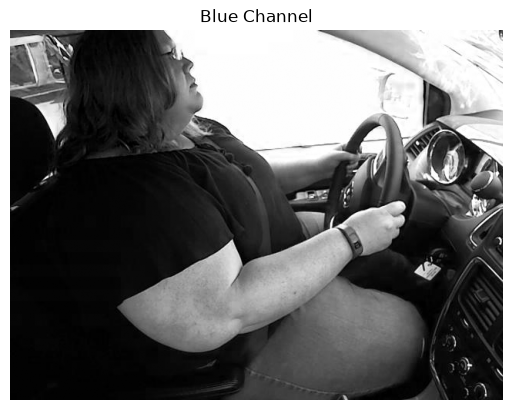

In [43]:
plt.imshow(blue_channel, cmap="gray")
plt.title("Blue Channel")
plt.axis("off")
plt.show()

In [44]:
def show_random_image(class_name):
    class_dir = Path("../data/raw/imgs/train") / class_name

    image_file = np.random.choice(list(class_dir.glob("*.jpg")))

    image = Image.open(image_file)

    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")
    plt.show()

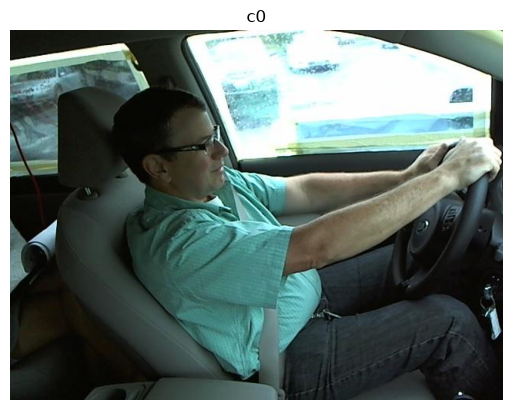

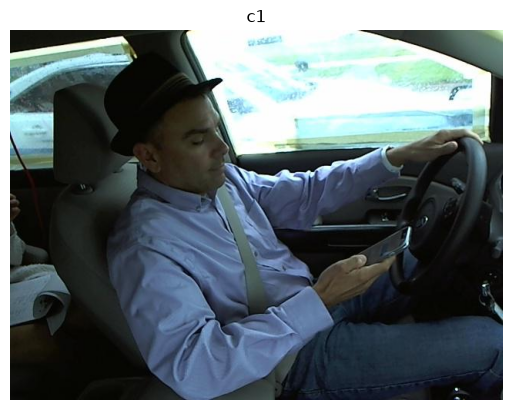

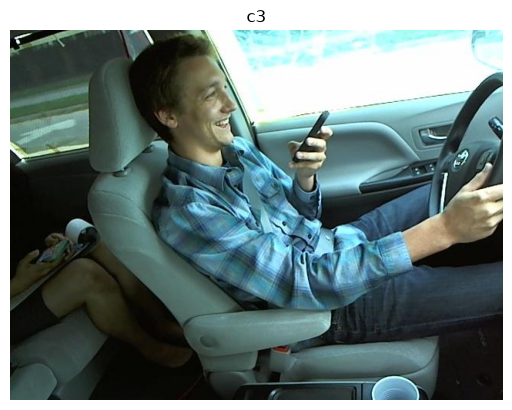

In [45]:
show_random_image("c0")
show_random_image("c1")
show_random_image("c3")

In [46]:
sizes = []

train_dir = Path("../data/raw/imgs/train")

for image_file in list(train_dir.glob("c*/*.jpg"))[:100]:
    image = Image.open(image_file)
    sizes.append(image.size)

print(set(sizes))

{(640, 480)}


In [47]:
# day 3 small test
image_path = Path("../data/raw/imgs/train/c9")
img_file = list(image_path.glob("*.jpg"))[0]
image = Image.open(image_file)
print(image_file)
print(image.size)
print(image.mode)
numpy_image = np.array(image)
print(numpy_image.shape)
print(numpy_image.min())
print(numpy_image.max())
sizes = []

train_dir = Path("../data/raw/imgs/train")

for image_file in list(train_dir.glob("c*/*.jpg"))[:100]:
    image = Image.open(image_file)
    sizes.append(image.size)

print(set(sizes))

../data/raw/imgs/train/c7/img_47130.jpg
(640, 480)
RGB
(480, 640, 3)
0
255
{(640, 480)}


# Converting Numpy to PyTorch Tensor

In [48]:
tensor_image = torch.from_numpy(numpy_image)

print(tensor_image.shape)

torch.Size([480, 640, 3])


In [49]:
tensor_image = tensor_image.permute(2, 0, 1)
tensor_image.shape

torch.Size([3, 480, 640])

In [50]:
print(tensor_image.dtype)

torch.uint8


In [51]:
tensor_image

tensor([[[ 29,  28,  26,  ...,  61,  92, 122],
         [ 28,  25,  25,  ...,  10,  24,  18],
         [ 27,  23,  24,  ...,   0,   0,   4],
         ...,
         [ 48,  47,  48,  ...,  14,  14,  14],
         [ 51,  51,  51,  ...,  14,  14,  14],
         [ 53,  55,  54,  ...,  14,  14,  14]],

        [[ 51,  50,  48,  ...,  76, 105, 135],
         [ 48,  47,  45,  ...,  28,  39,  33],
         [ 45,  43,  42,  ...,   9,  15,  23],
         ...,
         [ 65,  64,  65,  ...,   6,   6,   6],
         [ 66,  66,  68,  ...,   6,   6,   6],
         [ 68,  70,  71,  ...,   6,   6,   6]],

        [[ 38,  37,  35,  ...,  55,  87, 117],
         [ 36,  34,  33,  ...,   6,  20,  14],
         [ 33,  31,  30,  ...,   0,   0,   4],
         ...,
         [ 59,  58,  59,  ...,   4,   4,   4],
         [ 61,  61,  62,  ...,   4,   4,   4],
         [ 63,  65,  65,  ...,   4,   4,   4]]], dtype=torch.uint8)

In [52]:
tensor_image = tensor_image.float()

In [53]:
tensor_image

tensor([[[ 29.,  28.,  26.,  ...,  61.,  92., 122.],
         [ 28.,  25.,  25.,  ...,  10.,  24.,  18.],
         [ 27.,  23.,  24.,  ...,   0.,   0.,   4.],
         ...,
         [ 48.,  47.,  48.,  ...,  14.,  14.,  14.],
         [ 51.,  51.,  51.,  ...,  14.,  14.,  14.],
         [ 53.,  55.,  54.,  ...,  14.,  14.,  14.]],

        [[ 51.,  50.,  48.,  ...,  76., 105., 135.],
         [ 48.,  47.,  45.,  ...,  28.,  39.,  33.],
         [ 45.,  43.,  42.,  ...,   9.,  15.,  23.],
         ...,
         [ 65.,  64.,  65.,  ...,   6.,   6.,   6.],
         [ 66.,  66.,  68.,  ...,   6.,   6.,   6.],
         [ 68.,  70.,  71.,  ...,   6.,   6.,   6.]],

        [[ 38.,  37.,  35.,  ...,  55.,  87., 117.],
         [ 36.,  34.,  33.,  ...,   6.,  20.,  14.],
         [ 33.,  31.,  30.,  ...,   0.,   0.,   4.],
         ...,
         [ 59.,  58.,  59.,  ...,   4.,   4.,   4.],
         [ 61.,  61.,  62.,  ...,   4.,   4.,   4.],
         [ 63.,  65.,  65.,  ...,   4.,   4.,   4.]]]

In [54]:
print(tensor_image.dtype)

torch.float32


In [55]:
tensor_image = tensor_image / 255.0

In [56]:
print(tensor_image.min())
print(tensor_image.max())

tensor(0.)
tensor(1.)


In [57]:
image = Image.open(img_file)
numpy_arr = np.array(image)
tensor_arr = torch.from_numpy(numpy_arr)
print(tensor_arr.shape)
tensor_arr = tensor_arr.permute(2,0,1)
normalized_img = (tensor_arr / 255).float()

torch.Size([480, 640, 3])


In [58]:
def prepare_image(image_path):
    image = Image.open(image_path)
    numpy_image = np.array(image)
    tensor_image = torch.from_numpy(numpy_image)
    tensor_image = tensor_image.permute(2, 0, 1)
    tensor_image = tensor_image.float()
    tensor_image = tensor_image / 255.0
    return tensor_image

image_path = Path("../data/raw/imgs/train/c9")
img_file = list(image_path.glob("*.jpg"))[0]
prepared_image = prepare_image(image_file)

print(prepared_image.shape)
print(prepared_image.size())
print(prepared_image.dtype)
print(prepared_image.min())
print(prepared_image.max())

torch.Size([3, 480, 640])
torch.Size([3, 480, 640])
torch.float32
tensor(0.)
tensor(1.)


# Day 4

In [59]:
drivers = df["subject"].unique()

print(drivers)
print("Number of drivers:", len(drivers))

<StringArray>
['p002', 'p012', 'p014', 'p015', 'p016', 'p021', 'p022', 'p024', 'p026',
 'p035', 'p039', 'p041', 'p042', 'p045', 'p047', 'p049', 'p050', 'p051',
 'p052', 'p056', 'p061', 'p064', 'p066', 'p072', 'p075', 'p081']
Length: 26, dtype: str
Number of drivers: 26


In [63]:
rng = np.random.default_rng(42)
rng.shuffle(drivers)
print(drivers)

<StringArray>
['p081', 'p056', 'p016', 'p014', 'p041', 'p021', 'p047', 'p026', 'p022',
 'p035', 'p052', 'p042', 'p061', 'p024', 'p072', 'p075', 'p015', 'p050',
 'p066', 'p045', 'p064', 'p051', 'p012', 'p049', 'p002', 'p039']
Length: 26, dtype: str


/var/folders/tc/lzv0j8ss54v87b55nksfwjzr0000gn/T/ipykernel_34267/1839196868.py:2: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(drivers)


In [64]:
num_drivers = len(drivers)

train_size = int(num_drivers * 0.70)
val_size = int(num_drivers * 0.15)

print("Total:", num_drivers)
print("Train:", train_size)
print("Validation:", val_size)
print("Test:", num_drivers - train_size - val_size)

Total: 26
Train: 18
Validation: 3
Test: 5


In [65]:
train_drivers = drivers[:train_size]

val_drivers = drivers[
    train_size : train_size + val_size
]

test_drivers = drivers[
    train_size + val_size :
]

In [66]:
print("Train drivers:")
print(train_drivers)

print("\nValidation drivers:")
print(val_drivers)

print("\nTest drivers:")
print(test_drivers)

Train drivers:
<StringArray>
['p081', 'p056', 'p016', 'p014', 'p041', 'p021', 'p047', 'p026', 'p022',
 'p035', 'p052', 'p042', 'p061', 'p024', 'p072', 'p075', 'p015', 'p050']
Length: 18, dtype: str

Validation drivers:
<StringArray>
['p066', 'p045', 'p064']
Length: 3, dtype: str

Test drivers:
<StringArray>
['p051', 'p012', 'p049', 'p002', 'p039']
Length: 5, dtype: str


In [67]:
print(
    set(train_drivers)
    & set(val_drivers)
)

set()


In [68]:
print(set(train_drivers) & set(test_drivers))
print(set(val_drivers) & set(test_drivers))

set()
set()


In [70]:
train_df = df[df["subject"].isin(train_drivers)]

val_df = df[df["subject"].isin(val_drivers)]

test_df = df[df["subject"].isin(test_drivers)]

In [71]:
print("Total images:", len(df))
print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

Total images: 22424
Train images: 15716
Validation images: 2578
Test images: 4130


In [72]:
print(
    "All images accounted for:",
    len(train_df) + len(val_df) + len(test_df) == len(df)
)

All images accounted for: True


In [73]:
print("Train drivers:", train_df["subject"].nunique())
print("Validation drivers:", val_df["subject"].nunique())
print("Test drivers:", test_df["subject"].nunique())

Train drivers: 18
Validation drivers: 3
Test drivers: 5


In [74]:
print(train_df["classname"].value_counts().sort_index())

classname
c0    1711
c1    1613
c2    1605
c3    1660
c4    1630
c5    1615
c6    1632
c7    1408
c8    1333
c9    1509
Name: count, dtype: int64


In [75]:
print(val_df["classname"].value_counts().sort_index())

classname
c0    287
c1    256
c2    265
c3    260
c4    263
c5    262
c6    258
c7    232
c8    261
c9    234
Name: count, dtype: int64


In [76]:
print(test_df["classname"].value_counts().sort_index())

classname
c0    491
c1    398
c2    447
c3    426
c4    433
c5    435
c6    435
c7    362
c8    317
c9    386
Name: count, dtype: int64


In [77]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

In [78]:
train_df.to_csv(
    processed_dir / "train.csv",
    index=False
)

val_df.to_csv(
    processed_dir / "validation.csv",
    index=False
)

test_df.to_csv(
    processed_dir / "test.csv",
    index=False
)

In [79]:
check_train_df = pd.read_csv(
    processed_dir / "train.csv"
)

print(check_train_df.head())
print(check_train_df.shape)

  subject classname             img
0    p014        c0   img_72495.jpg
1    p014        c0   img_62101.jpg
2    p014        c0   img_34774.jpg
3    p014        c0  img_100312.jpg
4    p014        c0   img_12279.jpg
(15716, 3)


In [80]:
split_df = df.copy()

In [81]:
split_df["split"] = ""

In [82]:
split_df.loc[
    split_df["subject"].isin(train_drivers),
    "split"
] = "train"

In [83]:
split_df.loc[
    split_df["subject"].isin(val_drivers),
    "split"
] = "validation"

split_df.loc[
    split_df["subject"].isin(test_drivers),
    "split"
] = "test"

In [84]:
print(split_df.head())

  subject classname            img split
0    p002        c0  img_44733.jpg  test
1    p002        c0  img_72999.jpg  test
2    p002        c0  img_25094.jpg  test
3    p002        c0  img_69092.jpg  test
4    p002        c0  img_92629.jpg  test


In [85]:
print(split_df["split"].value_counts())

split
train         15716
test           4130
validation     2578
Name: count, dtype: int64


In [86]:
print(
    split_df.groupby("split")["subject"].nunique()
)

split
test           5
train         18
validation     3
Name: subject, dtype: int64


In [87]:
total_images = len(df)

train_percentage = len(train_df) / total_images * 100
val_percentage = len(val_df) / total_images * 100
test_percentage = len(test_df) / total_images * 100

print(f"Train: {train_percentage:.2f}%")
print(f"Validation: {val_percentage:.2f}%")
print(f"Test: {test_percentage:.2f}%")

Train: 70.09%
Validation: 11.50%
Test: 18.42%


In [88]:
split_df.to_csv(
    processed_dir / "dataset_splits.csv",
    index=False
)